In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
import keras_tuner as kt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

In [9]:
df = pd.read_csv('../data/engineered/dataset_mood_smartphone_ts.csv')
df = df.sort_values(["id", "date"])
df.head()

,id,date,activity,mood,screen,emotion,count_call_and_sms,total_app_use,social_ratio,productive_ratio,passive_entertainment_ratio,adventure_ratio,miscellaneous_ratio
0,AS14.01,2014-02-17,0.080856,7.075177,0.0,-0.185139,2,0.0,0.0,0.0,0.0,0.0,0.0
1,AS14.01,2014-02-18,0.080856,7.075177,0.0,-0.185139,1,0.0,0.0,0.0,0.0,0.0,0.0
2,AS14.01,2014-02-19,0.080856,7.075177,0.0,-0.185139,9,0.0,0.0,0.0,0.0,0.0,0.0
3,AS14.01,2014-02-20,0.080856,7.075177,0.0,-0.185139,5,0.0,0.0,0.0,0.0,0.0,0.0
4,AS14.01,2014-02-21,0.080856,7.075177,0.0,-0.185139,1,0.0,0.0,0.0,0.0,0.0,0.0


In [10]:
feature_cols = [
    "activity",
    "mood",
    "screen",
    "emotion",
    "count_call_and_sms",
    "total_app_use",
    "social_ratio",
    "productive_ratio",
    "passive_entertainment_ratio",
    "adventure_ratio",
    "miscellaneous_ratio",
]


def build_sequences(df, feature_cols, seq_len):
    """Build input sequences of given length."""
    X, y, groups = [], [], []
    for user_id, data in df.sort_values(["id", "date"]).groupby("id"):
        features = data[feature_cols].values
        moods = data["mood"].values
        for i in range(len(data) - seq_len):
            X.append(features[i : i + seq_len])
            y.append(moods[i + seq_len])
            groups.append(user_id)
    return np.array(X), np.array(y), np.array(groups)


best_seq, best_val_loss = None, float("inf")

for seq in [3, 5, 7]:
    X_tmp, y_tmp, g_tmp = build_sequences(df, feature_cols, seq)
    gkf_tmp = GroupKFold(n_splits=5)
    tr_idx, val_idx = next(gkf_tmp.split(X_tmp, y_tmp, g_tmp))

    scaler_tmp = StandardScaler()
    n_f = X_tmp.shape[2]
    X_tr = scaler_tmp.fit_transform(X_tmp[tr_idx].reshape(-1, n_f)).reshape(-1, seq, n_f)
    X_val = scaler_tmp.transform(X_tmp[val_idx].reshape(-1, n_f)).reshape(-1, seq, n_f)

    model_tmp = Sequential(
        [GRU(32, input_shape=(seq, n_f)), Dropout(0.2), Dense(1, activation="linear")]
    )
    model_tmp.compile(optimizer="adam", loss="mse", metrics=["mae"])
    hist = model_tmp.fit(
        X_tr,
        y_tmp[tr_idx],
        epochs=30,
        batch_size=32,
        validation_data=(X_val, y_tmp[val_idx]),
        verbose=0,
        callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
    )
    vl = min(hist.history["val_loss"])
    print(f"SEQ={seq}: val_loss={vl:.4f}, samples={len(X_tmp)}")
    if vl < best_val_loss:
        best_val_loss = vl
        best_seq = seq

print(f"\nBest sequence length: {best_seq}")

SEQ = best_seq
X, y, groups = build_sequences(df, feature_cols, SEQ)
n_features = X.shape[2]
n_timesteps = X.shape[1]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
groups_train = groups[train_idx]

print(f"\nX shape: {X.shape}  (samples, timesteps, features)")
print(f"Train: {len(X_train)}, Test: {len(X_test)}")
print(
    f"Train patients: {len(np.unique(groups_train))}, Test patients: {len(np.unique(groups[test_idx]))}"
)
print(f"Features: {feature_cols}")

/home/milou/Documents/school/master/data-mining-techniques/DMT_Assignment_1/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


SEQ=3: val_loss=0.3428, samples=1892


/home/milou/Documents/school/master/data-mining-techniques/DMT_Assignment_1/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


SEQ=5: val_loss=0.3375, samples=1838


/home/milou/Documents/school/master/data-mining-techniques/DMT_Assignment_1/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


SEQ=7: val_loss=0.3454, samples=1784

Best sequence length: 5

X shape: (1838, 5, 11)  (samples, timesteps, features)
Train: 1445, Test: 393
Train patients: 21, Test patients: 6
Features: ['activity', 'mood', 'screen', 'emotion', 'count_call_and_sms', 'total_app_use', 'social_ratio', 'productive_ratio', 'passive_entertainment_ratio', 'adventure_ratio', 'miscellaneous_ratio']


In [11]:
def build_gru(hp):
    units = hp.Choice("units", [32, 64, 128])
    dropout = hp.Choice("dropout", [0.2, 0.4])
    lr = hp.Choice("learning_rate", [0.001, 0.0005])
    bidirectional = hp.Boolean("bidirectional")
    n_layers = hp.Choice("n_layers", [1, 2])

    model = Sequential()
    for i in range(n_layers):
        return_seq = (i < n_layers - 1)
        if bidirectional:
            model.add(
                Bidirectional(
                    GRU(units, return_sequences=return_seq), input_shape=(n_timesteps, n_features)
                )
            )
        else:
            model.add(GRU(units, return_sequences=return_seq, input_shape=(n_timesteps, n_features)))
        model.add(Dropout(dropout))

    model.add(Dense(32, activation="relu"))
    model.add(Dropout(dropout / 2))
    model.add(Dense(1, activation="linear"))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="mse",
        metrics=["mae"],
    )
    return model

# Tune on the training set only
scaler_tune = StandardScaler()
X_train_scaled = scaler_tune.fit_transform(
    X_train.reshape(-1, n_features)
).reshape(X_train.shape)

gru_tuner = kt.RandomSearch(
    build_gru,
    objective="val_loss",
    max_trials=30,
    directory="keras_tuner_logs",
    project_name="gru_mood_regression",
    overwrite=True,
)

gru_tuner.search(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=0
)

gru_tuner.results_summary(num_trials=5)

/home/milou/Documents/school/master/data-mining-techniques/DMT_Assignment_1/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/home/milou/Documents/school/master/data-mining-techniques/DMT_Assignment_1/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Results summary
Results in keras_tuner_logs/gru_mood_regression
Showing 5 best trials
Objective(name="val_loss", direction="min")

Trial 09 summary
Hyperparameters:
units: 32
dropout: 0.4
learning_rate: 0.001
bidirectional: True
n_layers: 2
Score: 0.21143506467342377

Trial 03 summary
Hyperparameters:
units: 64
dropout: 0.4
learning_rate: 0.001
bidirectional: True
n_layers: 2
Score: 0.22366061806678772

Trial 14 summary
Hyperparameters:
units: 32
dropout: 0.2
learning_rate: 0.001
bidirectional: False
n_layers: 2
Score: 0.23254038393497467

Trial 17 summary
Hyperparameters:
units: 128
dropout: 0.2
learning_rate: 0.001
bidirectional: False
n_layers: 1
Score: 0.23345987498760223

Trial 07 summary
Hyperparameters:
units: 64
dropout: 0.2
learning_rate: 0.001
bidirectional: True
n_layers: 1
Score: 0.23506991565227509


In [12]:
best_gru_hp = gru_tuner.get_best_hyperparameters()[0]

# Scale using train set statistics
scaler = StandardScaler()
X_train_final = scaler.fit_transform(
    X_train.reshape(-1, n_features)
).reshape(X_train.shape)
X_test_final = scaler.transform(
    X_test.reshape(-1, n_features)
).reshape(X_test.shape)

tf.random.set_seed(42)
np.random.seed(42)

model = build_gru(best_gru_hp)
model.fit(
    X_train_final, y_train,
    epochs=50, batch_size=32,
    validation_split=0.2,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=0
)

y_pred = model.predict(X_test_final, verbose=0).flatten()

/home/milou/Documents/school/master/data-mining-techniques/DMT_Assignment_1/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


=== Test Set Results (GRU Regression) ===
MAE:  0.3640
MSE:  0.2556
R²:   0.2605


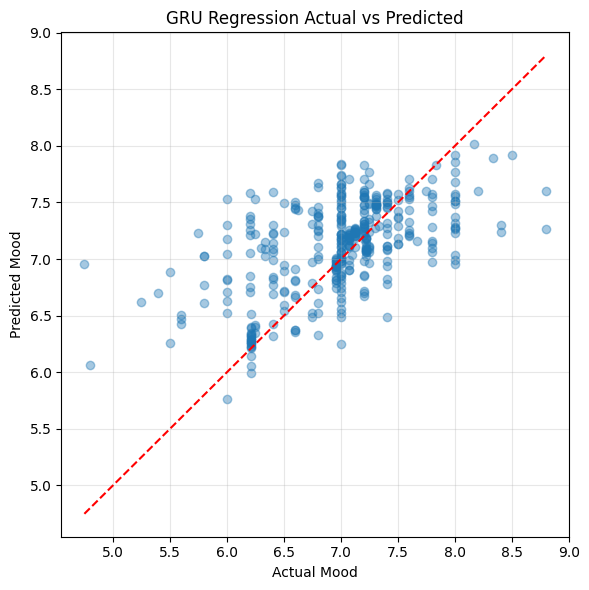

In [17]:
print("=== Test Set Results (GRU Regression) ===")
print(f"MAE:  {mean_absolute_error(y_test, y_pred):.4f}")
print(f"MSE:  {mean_squared_error(y_test, y_pred):.4f}")
print(f"R²:   {r2_score(y_test, y_pred):.4f}")

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Mood')
plt.ylabel('Predicted Mood')
plt.title('GRU Regression Actual vs Predicted')
plt.tight_layout()
plt.grid(alpha=0.3)
plt.savefig('gru_mood_regression_scatter.pdf')
plt.show()